# Convolutional Neural Network For Handwritten Digit Recognition Using Tensorflow

## Importing Essential Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns 

from PIL import Image

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import image_dataset_from_directory

## Inspecting the Dataset

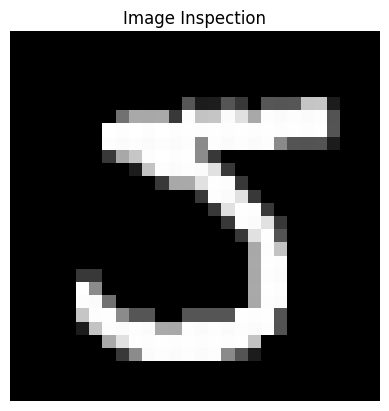

In [18]:
inspection_img = Image.open("../data/mnistmini/training/5/23734.png")

plt.title("Image Inspection")

plt.imshow(inspection_img, cmap = "gray")
plt.axis("off")

plt.show()


## Loading Dataset

In [49]:
train_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "training",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32
)

validation_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "validation",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32
)

test_dataset = image_dataset_from_directory(
    "../data/mnistmini/testing",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32,
    shuffle = False
)

Found 1000 files belonging to 10 classes.
Using 800 files for training.
Found 1000 files belonging to 10 classes.
Using 200 files for validation.
Found 200 files belonging to 10 classes.


## Model 1 Architecture and Creation

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomTranslation(0.1, 0.1)
])

In [18]:
model = models.Sequential([
    tf.keras.Input(shape = (28, 28, 1)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation = "relu"),
    layers.Dense(10)
])

In [19]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)

In [21]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 50
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2125 - loss: 2.2124 - val_accuracy: 0.5300 - val_loss: 1.8250
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4750 - loss: 1.6913 - val_accuracy: 0.7300 - val_loss: 0.8774
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6025 - loss: 1.2209 - val_accuracy: 0.7950 - val_loss: 0.6402
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6787 - loss: 0.9938 - val_accuracy: 0.8400 - val_loss: 0.4647
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7462 - loss: 0.7726 - val_accuracy: 0.8450 - val_loss: 0.4145
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7887 - loss: 0.6626 - val_accuracy: 0.8900 - val_loss: 0.3203
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8388 - loss: 0.5211 - val_accuracy: 0.9450 - val_loss: 0.2451
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8375 - loss: 0.5451 - val_accuracy: 0.9000 - v

## Model 2 Architecture and Creation

In [56]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomTranslation(0.05, 0.05)
])

In [57]:
modern_model = models.Sequential([
    tf.keras.Input(shape = (28, 28, 1)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation = "relu"),

    layers.Dropout(0.3),

    layers.Dense(10)
])

In [58]:
modern_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,482 (771.41 KB)

 Trainable params: 197,482 (771.41 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps = 1000,
    decay_rate = 0.95
)

In [60]:
modern_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = lr_schedule),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits = True
    ),
    metrics = ['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_accuracy",
    patience = 5,
    restore_best_weights = True
)

In [61]:
history = modern_model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 30,
    callbacks = [
        early_stopping
    ]
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.3525 - loss: 1.9630 - val_accuracy: 0.6650 - val_loss: 0.9484
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6862 - loss: 0.9883 - val_accuracy: 0.8900 - val_loss: 0.3812
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8000 - loss: 0.6235 - val_accuracy: 0.8900 - val_loss: 0.2900
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8388 - loss: 0.4965 - val_accuracy: 0.9400 - val_loss: 0.2461
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8763 - loss: 0.3722 - val_accuracy: 0.9250 - val_loss: 0.2224
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9062 - loss: 0.2855 - val_accuracy: 0.9500 - val_loss: 0.1978
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9312 - loss: 0.2517 - val_accuracy: 0.9550 - val_loss: 0.1670
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9362 - loss: 0.1985 - val_accuracy: 0.9500 - v

## Model Evaluation

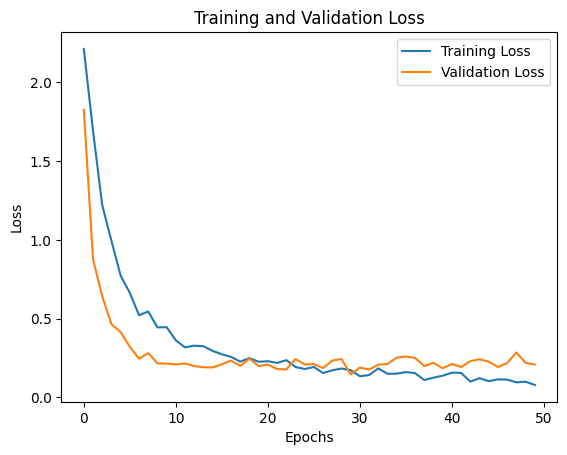

In [22]:
plt.title("Training and Validation Loss")

plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
# plt.grid(True)

plt.show()

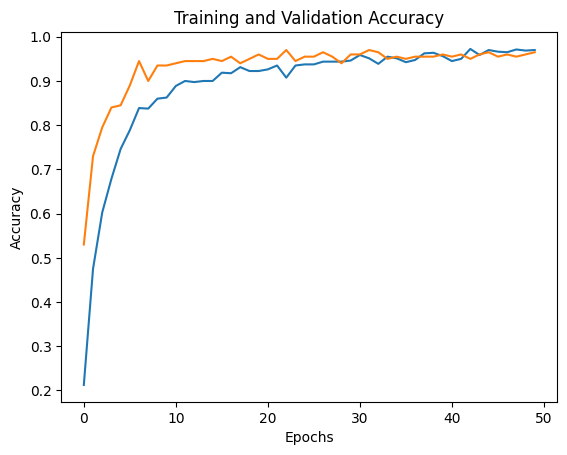

In [23]:
plt.title("Training and Validation Accuracy")

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

In [24]:
y_true = np.concatenate([y for x, y in test_dataset])

logits = model.predict(test_dataset)
y_preds = np.argmax(logits, axis = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


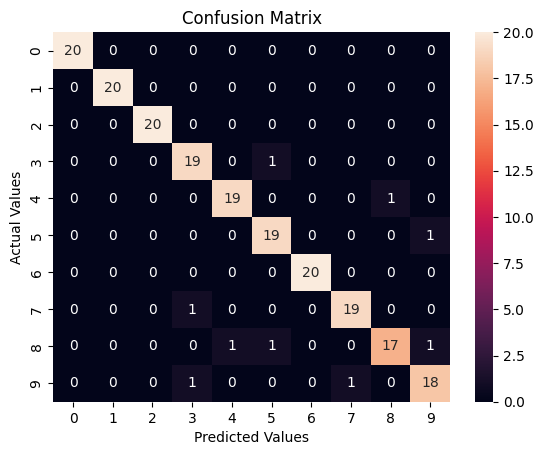

In [26]:
cm = confusion_matrix(y_true, y_preds)

plt.title("Confusion Matrix")

sns.heatmap(cm, annot = True)
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

plt.show()

In [27]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       0.90      0.95      0.93        20
           4       0.95      0.95      0.95        20
           5       0.90      0.95      0.93        20
           6       1.00      1.00      1.00        20
           7       0.95      0.95      0.95        20
           8       0.94      0.85      0.89        20
           9       0.90      0.90      0.90        20

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200



## Saving the Model and Making Inferences

In [28]:
model.save("../models/cnn_digit_tensorflow_model.keras")

In [6]:
saved_model = models.load_model("../models/cnn_digit_tensorflow_model.keras")

In [8]:
def predict_digit(image_path):
    image = Image.open(image_path).convert("L")
    
    plt.title("Acutal Digit")
    plt.imshow(image, cmap = "gray")
    plt.axis("off")
    plt.show()

    image = image.resize((28, 28))

    img_array = np.array(image, dtype = np.float32)
    img_array = np.expand_dims(img_array, axis = -1)
    img_array = np.expand_dims(img_array, axis = 0)

    logits = saved_model.predict(img_array, verbose = 0)
    predicted_digit = np.argmax(logits, axis = 1)

    print(f"Predicted Digit: {predicted_digit[0]}")

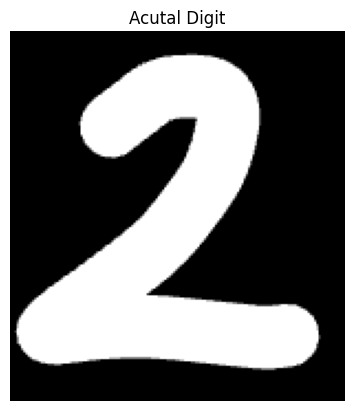

Predicted Digit: 2


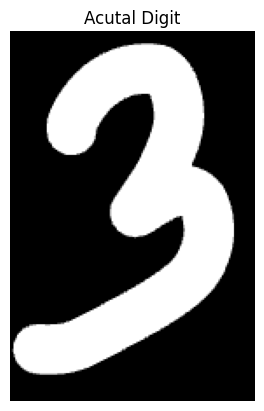

Predicted Digit: 3


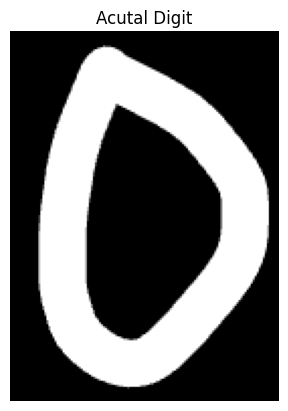

Predicted Digit: 0


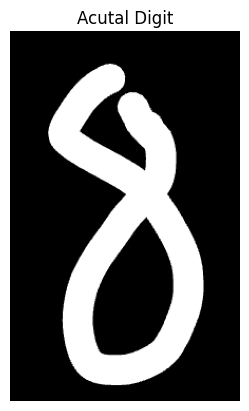

Predicted Digit: 3


In [9]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Eight.png')